In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

In [5]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

In [6]:
!wget $data -O course_lead_scoring_2026.csv

--2026-10-03 06:45:15--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘course_lead_scoring_2026.csv’

course_lead_scoring 100%[===================>] 272.21K  --.-KB/s    in 0.007s  

2026-10-03 06:45:15 (37.6 MB/s) - ‘course_lead_scoring_2026.csv’ saved [278746/278746]



In [7]:
df = pd.read_csv(data)

In [8]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [9]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [10]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')


In [11]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [12]:
numerical = df.select_dtypes(include=['number']).columns.drop(labels=['converted']).to_list()
categorical = df.select_dtypes(exclude=['number']).columns.to_list()

In [13]:
df[numerical] = df[numerical].fillna(0.0)
df[categorical] = df[categorical].fillna('NA')

In [14]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [15]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

In [16]:
df_train = df_train.drop(columns=['converted'])
df_val = df_val.drop(columns=['converted'])
df_test = df_test.drop(columns=['converted'])

In [17]:

for feature in numerical:
    score = roc_auc_score(y_train, df_train[feature])
    
    if score < 0.5:
        score = roc_auc_score(y_train, -df_train[feature])
        
    print(f"{feature}: {score:.3f}")

annual_income: 0.608
number_of_courses_viewed: 0.723
interaction_count: 0.765
lead_score: 0.788


In [18]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=1)
model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The E

In [19]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.651)

In [20]:
round(roc_auc_score(y_val, y_pred), 3)

0.732

In [21]:
from sklearn.metrics import precision_score, recall_score

In [22]:
thresholds = np.arange(0.0, 1.01, 0.01)
p_list = []
r_list = []

for t in thresholds:
  # churn_decision = (y_pred >= t)
  # p = precision_score(y_val, churn_decision, zero_division=0)
  # r = recall_score(y_val, churn_decision, zero_division=0)
  actual_positive = (y_val == 1)
  actual_negative = (y_val == 0)
  
  predict_positive = (y_pred >= t)
  predict_negative = (y_pred < t)
  
  tp = (predict_positive & actual_positive).sum()
  fp = (predict_positive & actual_negative).sum()
  fn = (predict_negative & actual_positive).sum()
  
  p = tp / (tp + fp) if (tp + fp) > 0 else 1.0
  r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
  p_list.append(p)
  r_list.append(r)

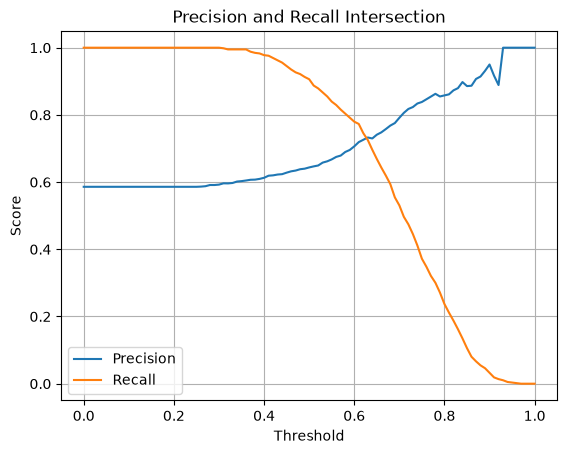

In [23]:
import matplotlib.pyplot as plt

plt.plot(thresholds, p_list, label='Precision')
plt.plot(thresholds, r_list, label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall Intersection')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import numpy as np

# Convert lists to numpy arrays
p_array = np.array(p_list)
r_array = np.array(r_list)

# Find index of minimum difference
diff = np.abs(p_array - r_array)
min_idx = np.argmin(diff)

intersection_threshold = thresholds[min_idx]
print(f"Intersection Threshold: {intersection_threshold:.2f}")
print(f"Precision: {p_array[min_idx]:.3f}, Recall: {r_array[min_idx]:.3f}")

Intersection Threshold: 0.63
Precision: 0.733, Recall: 0.725


In [25]:
p_list

[np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.586),
 np.float64(0.5865865865865866),
 np.float64(0.5877632898696088),
 np.float64(0.591321897073663),
 np.float64(0.591321897073663),
 np.float64(0.5925176946410515),
 np.float64(0.5963302752293578),
 np.float64(0.5961145194274029),
 np.float64(0.5973360655737705),
 np.float64(0.6016511867905057),
 np.float64(0.6028955532574974),
 np.float64(0.6047717842323651),
 np.float64(0.6069182389937107),
 np.float64(0.6073684210526316),
 np.float64(0.6095238095238096),
 np.float64(0.612834

In [26]:
p = p_array
r = r_array

f1_scores = np.where((p + r) > 0, 2 * (p * r) / (p + r), 0)

max_idx = np.argmax(f1_scores)
print(f"Max F1 score: {f1_scores[max_idx]:.3f} at threshold: {thresholds[max_idx]:.2f}")

Max F1 score: 0.758 at threshold: 0.41


In [27]:
from sklearn.model_selection import KFold

In [35]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=3000)
    model.fit(X_train, y_train)
    
    return dv, model

In [30]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [31]:
!pip install tqdm

In [33]:
from tqdm.auto import tqdm

In [38]:
n_splits = 5
C = 1.0
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train, C=C)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1.0 0.792 +- 0.013


In [40]:
n_splits = 5

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06 0.615 +- 0.019
C=0.001 0.783 +- 0.013
C=1 0.792 +- 0.013
